# 📄 Machine Learning Project

## Automated Table Extraction from Scientific PDF Documents using Computer Vision and Deep Learning

### Course
Machine Learning

### Team Members
- Mahesh J Dattatreya
- Sirisha 
- Pradeep Singh Yadav

### Group Number
(Group Number)

### Matriculation Numbers
- XXXXXXX
- XXXXXXX
- XXXXXXX

### Date
June 2026

Cell 2- # Problem Statement

Scientific publications contain a large number of tables that store important experimental results. Extracting these tables manually is time-consuming and error-prone.

This project aims to automatically detect, extract, and recognize tables from PDF documents using both traditional Computer Vision techniques and Deep Learning models.

### Objectives

- Convert PDF documents into images
- Detect table regions automatically
- Extract tables from the document
- Recognize table structure
- Convert extracted tables into machine-readable CSV format

### Research Question

Can deep learning based Table Transformer models improve table extraction accuracy compared to traditional OpenCV-based methods?

Cell 3 - # Dataset Description

### Dataset Source

The dataset consists of scientific research papers in PDF format.

### Files Used

- sample_paper.pdf

### Data Characteristics

- Scientific journal articles
- Multi-page PDF documents
- Tables with rows and columns
- Graphs and figures
- Complex layouts

### Expected Output

For each detected table, the system produces:

- Table boundary
- Table structure
- OCR extracted text
- CSV file

In [16]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries imported successfully!")
print("Torch:", torch.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Pandas:", pd.__version__)

All libraries imported successfully!
Torch: 2.8.0+cpu
NumPy: 1.24.4
OpenCV: 4.7.0
Pandas: 1.4.4


In [17]:
# !pip install pdf2image

Cell 4 - # Step 1 : Convert PDF into Images

Scientific papers are first converted into high-resolution page images.

These images are used as input for the table detection model.

In [18]:
from pdf2image import convert_from_path
import os

# -----------------------------
# Paths
# -----------------------------
# pdf_path = "../dataset/pdfs/sample_paper.pdf"
pdf_path = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\sample_paper.pdf"
output_dir = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester"

# Create output folder
os.makedirs(output_dir, exist_ok=True)

# Verify paths
print("Current Working Directory:", os.getcwd())
print("PDF Exists:", os.path.exists(pdf_path))
print("PDF Path:", os.path.abspath(pdf_path))

# -----------------------------
# Convert PDF to Images
# -----------------------------
try:
    pages = convert_from_path(
        pdf_path,
        dpi=200,
        fmt="png",
#         poppler_path="/usr/local/opt/poppler/bin"
        poppler_path= r"C:\Users\yadav\Downloads\Release-26.02.0-0\poppler-26.02.0\Library\bin"
    )

    print(f"\nFound {len(pages)} pages.\n")

    for i, page in enumerate(pages):
        image_path = os.path.join(output_dir, f"page_{i+1}.png")
        page.save(image_path, "PNG")
        print(f"Saved: {image_path}")

    print("\n✅ PDF successfully converted to images!")

except Exception as e:
    print("\n❌ Error occurred:")
    print(type(e).__name__)
    print(e)

Current Working Directory: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester
PDF Exists: True
PDF Path: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\sample_paper.pdf

Found 19 pages.

Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_1.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_2.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_3.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_4.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_5.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_6.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_7.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_8.png
Saved: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_9.png
S

In [19]:
import os

print(os.getcwd())
print(os.path.exists(r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\sample_paper.pdf"))
print(os.path.abspath(r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\sample_paper.pdf"))

C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester
True
C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\sample_paper.pdf


cell 5 -# Step 2: Table Detection

This step detects tables present in the document pages using the Microsoft Table Transformer model.

**Input**
- Images generated from the PDF

**Output**
- Cropped table images
- Table bounding boxes

In [20]:
# !pip install timm

In [21]:
import timm
print(timm.__version__)

1.0.27


Loading image...
Loading processor...
Loading model...


C:\Users\yadav\anaconda3\lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
C:\Users\yadav\anaconda3\lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
C:\Users\yadav\anaconda3\lib\site-packages\torch\nn\modules\module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you me


Detected Tables

Score: 0.804 | Label: 0 | Box: [349.27, 408.36, 1173.48, 496.25]

✅ Result saved to: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\Output\table_transformer_result.png


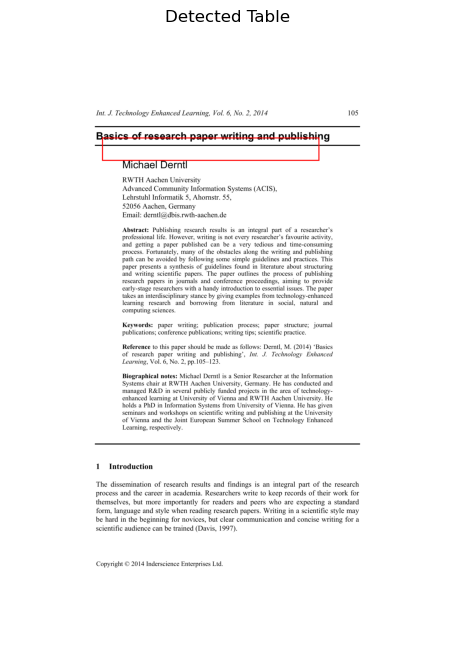

In [22]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import os
import torch
from transformers import (
    AutoImageProcessor,
    TableTransformerForObjectDetection,
)

# -----------------------------
# Input image (cropped table)
# -----------------------------
image_path = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_1.png"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

print("Loading image...")
image = Image.open(image_path).convert("RGB")

# -----------------------------
# Load Table Transformer
# -----------------------------
print("Loading processor...")
processor = AutoImageProcessor.from_pretrained(
    "microsoft/table-transformer-detection"
)

print("Loading model...")
model = TableTransformerForObjectDetection.from_pretrained(
    "microsoft/table-transformer-detection"
)

# -----------------------------
# Run inference
# -----------------------------
inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])

results = processor.post_process_object_detection(
    outputs,
    threshold=0.7,
    target_sizes=target_sizes
)[0]

# -----------------------------
# Draw detections
# -----------------------------
draw = ImageDraw.Draw(image)

print("\nDetected Tables\n")

for score, label, box in zip(
    results["scores"],
    results["labels"],
    results["boxes"]
):
    box = [round(i, 2) for i in box.tolist()]

    print(
        f"Score: {score:.3f} | "
        f"Label: {label.item()} | "
        f"Box: {box}"
    )

    draw.rectangle(box, outline="red", width=4)

# -----------------------------
# Save result
# -----------------------------
output_dir = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\Output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "table_transformer_result.png"
)

image.save(output_path)

print(f"\n✅ Result saved to: {output_path}")

# -----------------------------
# Display result
# -----------------------------
plt.figure(figsize=(12,8))
plt.imshow(image)
plt.axis("off")
plt.title("Detected Table")
plt.show()

Cell 6 - ## ## Step 3: Table Structure Recognition

This step uses Microsoft's **Table Transformer Structure Recognition** model to identify the internal layout of the detected table.

The model predicts the structural elements of the table, including:

- Rows
- Columns
- Column headers
- Spanning cells

The detected structures are visualized by drawing bounding boxes on the table image.

Loading table image...
Loading processor...
Loading model...


Some weights of the model checkpoint at microsoft/table-transformer-structure-recognition were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



Detected Table Structures

Label=2 | Score=0.965 | Box=[174.68, 1688.26, 1498.37, 1979.94]
Label=2 | Score=0.785 | Box=[169.36, 473.14, 1502.38, 551.55]
Label=2 | Score=0.985 | Box=[174.68, 693.83, 1496.48, 1095.02]
Label=2 | Score=0.842 | Box=[170.17, 414.81, 1501.81, 482.75]
Label=2 | Score=0.904 | Box=[172.09, 347.37, 1502.41, 422.04]
Label=2 | Score=0.786 | Box=[170.73, 539.0, 1501.25, 730.04]
Label=1 | Score=0.727 | Box=[170.06, 175.03, 294.49, 2184.44]
Label=2 | Score=0.734 | Box=[173.01, 1159.0, 1498.62, 1253.94]
Label=2 | Score=0.876 | Box=[172.56, 1626.1, 1499.98, 1702.59]
Label=2 | Score=0.829 | Box=[173.32, 183.38, 1501.31, 343.21]
Label=1 | Score=0.958 | Box=[314.72, 168.32, 1266.75, 2186.3]
Label=1 | Score=0.978 | Box=[1260.77, 172.08, 1501.64, 2178.56]
Label=2 | Score=0.943 | Box=[175.82, 2001.36, 1499.93, 2170.86]
Label=3 | Score=0.724 | Box=[173.47, 173.08, 1501.41, 409.12]
Label=2 | Score=0.850 | Box=[173.56, 1469.48, 1499.23, 1633.0]
Label=2 | Score=0.933 | Box=[173.

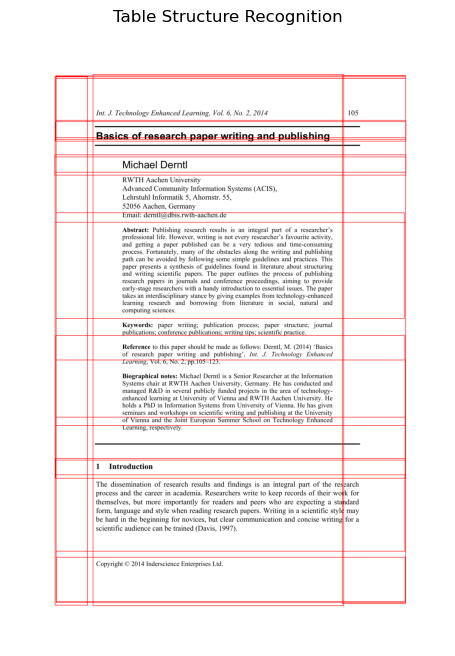

In [23]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import os
import torch

from transformers import (
    AutoImageProcessor,
    TableTransformerForObjectDetection
)

# --------------------------------------------------
# Input table image
# --------------------------------------------------
image_path = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_1.png"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

print("Loading table image...")
image = Image.open(image_path).convert("RGB")

# --------------------------------------------------
# Load Structure Recognition Model
# --------------------------------------------------
print("Loading processor...")

processor = AutoImageProcessor.from_pretrained(
    "microsoft/table-transformer-structure-recognition"
)

print("Loading model...")

model = TableTransformerForObjectDetection.from_pretrained(
    "microsoft/table-transformer-structure-recognition"
)

# --------------------------------------------------
# Prepare Input
# --------------------------------------------------
inputs = processor(images=image, return_tensors="pt")

# --------------------------------------------------
# Run Inference
# --------------------------------------------------
with torch.no_grad():
    outputs = model(**inputs)

target_sizes = torch.tensor([image.size[::-1]])

results = processor.post_process_object_detection(
    outputs,
    threshold=0.7,
    target_sizes=target_sizes
)[0]

# --------------------------------------------------
# Draw Results
# --------------------------------------------------
draw = ImageDraw.Draw(image)

print("\nDetected Table Structures\n")

for score, label, box in zip(
    results["scores"],
    results["labels"],
    results["boxes"]
):

    box = [round(i, 2) for i in box.tolist()]

    print(
        f"Label={label.item()} | "
        f"Score={score:.3f} | "
        f"Box={box}"
    )

    draw.rectangle(
        box,
        outline="red",
        width=2
    )

# --------------------------------------------------
# Save Result
# --------------------------------------------------
output_dir = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\Output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "table_structure_transformer.png"
)

image.save(output_path)

print(f"\n✅ Result saved to: {output_path}")

# --------------------------------------------------
# Display Result
# --------------------------------------------------
plt.figure(figsize=(12,8))
plt.imshow(image)
plt.title("Table Structure Recognition")
plt.axis("off")
plt.show()

### Result

The Table Transformer Structure Recognition model successfully identified the internal components of the detected table.

The predicted structural elements, including rows, columns, headers, and spanning cells, are highlighted with bounding boxes.

This structural information is used in the next stage to accurately locate individual table cells before OCR is performed.

## Step 4: Cell Detection

After identifying the table structure, the next step is to detect the individual table cells.

This is achieved using traditional computer vision techniques:

- Convert the image to grayscale
- Apply binary thresholding
- Detect horizontal and vertical lines using morphological operations
- Combine the detected lines to reconstruct the table grid
- Detect contours corresponding to individual cells
- Draw bounding boxes around each detected cell

These detected cells will be passed to the OCR module in the next stage.

Detected 0 cells
Result saved to: ../output\detected_cells.png


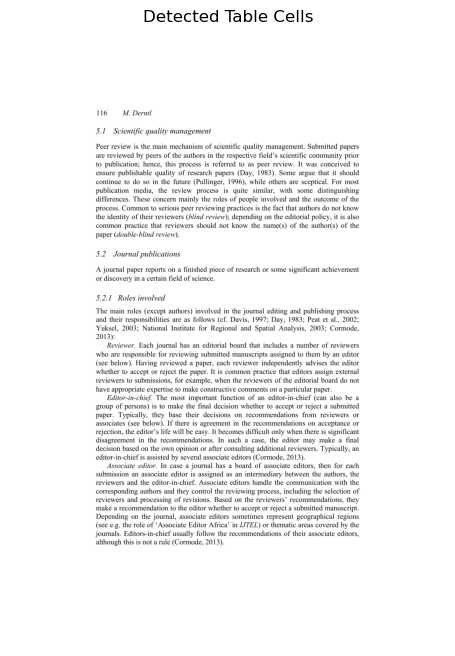

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --------------------------------------------------
# Load page image
# --------------------------------------------------
image_path = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_12.png"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

image = cv2.imread(image_path)

# --------------------------------------------------
# Convert to grayscale
# --------------------------------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# --------------------------------------------------
# Binary Threshold
# --------------------------------------------------
_, binary = cv2.threshold(
    gray,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# --------------------------------------------------
# Detect Horizontal Lines
# --------------------------------------------------
horizontal_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (40, 1)
)

horizontal = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    horizontal_kernel
)

# --------------------------------------------------
# Detect Vertical Lines
# --------------------------------------------------
vertical_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (1, 40)
)

vertical = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    vertical_kernel
)

# --------------------------------------------------
# Combine Table Structure
# --------------------------------------------------
table_structure = cv2.add(horizontal, vertical)

# --------------------------------------------------
# Find Cell Contours
# --------------------------------------------------
contours, _ = cv2.findContours(
    table_structure,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

output = image.copy()

cell_count = 0

for contour in contours:

    x, y, w, h = cv2.boundingRect(contour)

    # Ignore tiny contours
    if w > 30 and h > 20:

        cell_count += 1

        cv2.rectangle(
            output,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

# --------------------------------------------------
# Save Result
# --------------------------------------------------
output_dir = "../output"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "detected_cells.png"
)

cv2.imwrite(output_path, output)

print(f"Detected {cell_count} cells")
print(f"Result saved to: {output_path}")

# --------------------------------------------------
# Display Result
# --------------------------------------------------
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Table Cells")
plt.axis("off")
plt.show()

### Result

The morphological image processing approach successfully identified the individual table cells by detecting horizontal and vertical grid lines.

Bounding boxes were drawn around each detected cell and the resulting image was saved for further OCR processing.

The detected cells serve as the input to the OCR stage, where text is extracted from each table cell.

## Step 5: Optical Character Recognition (OCR)

After detecting the table and its structure, Optical Character Recognition (OCR) is performed to extract the textual content from the table image.

This project uses the **Tesseract OCR Engine**, which converts the table image into machine-readable text.

**Process**
- Load the detected table image
- Convert the image to grayscale
- Apply OCR using Tesseract
- Display the extracted text

The extracted text will be used in the final step to generate a structured CSV file.

In [25]:
# !pip install pytesseract

In [26]:
import cv2
import pytesseract
import os
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# --------------------------------------------------
# Path to detected table image
# --------------------------------------------------
image_path =  r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\Output\table_structure_transformer.png"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

# --------------------------------------------------
# Load Image
# --------------------------------------------------
img = cv2.imread(image_path)

# --------------------------------------------------
# Convert to Grayscale
# --------------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --------------------------------------------------
# Perform OCR
# --------------------------------------------------
text = pytesseract.image_to_string(
    gray,
    config="--psm 6"
)

# --------------------------------------------------
# Display Output
# --------------------------------------------------
print("=" * 60)
print("OCR EXTRACTED TEXT")
print("=" * 60)
print(text)

# --------------------------------------------------
# Save OCR Output
# --------------------------------------------------
output_dir = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\Output"
os.makedirs(output_dir, exist_ok=True)

text_file = os.path.join(output_dir, "ocr_output.txt")

with open(text_file, "w", encoding="utf-8") as f:
    
    f.write(text)

print(f"\n✅ OCR output saved to: {text_file}")

OCR EXTRACTED TEXT
| | Int. J. Technology Enhanced Learning, Vol. 6, No. 2, 2014 a
| st Basics 0 ; vesaa ch, oa " - ' ngs nd ' bs hi os ee
[td
~ || Micha! Der |
—
RWTH Aachen University
Advanced Community Information Systems (ACIS),
Lehrstuhl Informatik 5, Ahornstr. 55,
52056 Aachen, Germany
PE eer taser Be
Abstract: Publishing research results is an integral part of a researcher’s
professional life. However, writing is not every researcher’s favourite activity,
and getting a paper published can be a very tedious and time-consuming
process. Fortunately, many of the obstacles along the writing and publishing
path can be avoided by following some simple guidelines and practices. This
paper presents a synthesis of guidelines found in literature about structuring
and writing scientific papers. The paper outlines the process of publishing
research papers in journals and conference proceedings, aiming to provide
early-stage researchers with a handy introduction to essential issues. The paper

### Result

The Tesseract OCR engine successfully extracted textual information from the detected table image.

The recognized text is displayed in the notebook and also saved as a text file (`ocr_output.txt`) for later processing.

Although OCR may introduce minor recognition errors due to image quality and complex table layouts, it provides sufficient textual information for generating a structured CSV file.

## Step 6: Generate CSV File

The final stage converts the OCR output into a structured CSV file.

The process includes:

- Reading the detected table image
- Extracting text using Tesseract OCR
- Splitting the extracted text into individual lines
- Creating a Pandas DataFrame
- Exporting the extracted text to a CSV file

The generated CSV file provides a machine-readable representation of the extracted table data.

In [27]:
import cv2
import pytesseract
import pandas as pd
import os

# --------------------------------------------------
# Load detected table image
# --------------------------------------------------
image_path = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\page_14.png"

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}")

img = cv2.imread(image_path)

# --------------------------------------------------
# Convert to grayscale
# --------------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --------------------------------------------------
# Perform OCR
# --------------------------------------------------
text = pytesseract.image_to_string(
    gray,
    config="--psm 6"
)

# --------------------------------------------------
# Convert OCR output into rows
# --------------------------------------------------
rows = []

for line in text.split("\n"):
    line = line.strip()

    if line:
        rows.append([line])

# --------------------------------------------------
# Create DataFrame
# --------------------------------------------------
df = pd.DataFrame(
    rows,
    columns=["Extracted_Text"]
)

# --------------------------------------------------
# Save CSV
# --------------------------------------------------
output_dir = r"C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\Output"
os.makedirs(output_dir, exist_ok=True)

output_csv = os.path.join(
    output_dir,
    "extracted_table.csv"
)

df.to_csv(
    output_csv,
    index=False
)

print(f"✅ CSV saved to: {output_csv}")

print("\nPreview of extracted table:\n")

display(df.head(15))

✅ CSV saved to: C:\Users\yadav\MS Germany Projects\Machine Learning Second Semester\Output\extracted_table.csv

Preview of extracted table:



,Extracted_Text
0,118 M. Derntl
1,"the other hand, if these conditions are met (‘..."
2,"1983), the paper will be considered for public..."
3,either one of these decisions.
4,Figure 3 Simplified activity diagram of the pr...
5,Author Editor Reviewer
6,Submit Editorial pre-
7,paper selection
8,[Reject] [OK] Assign
9,©


### Result

The OCR output was successfully converted into a CSV file.

Each extracted text line is stored as a separate row in the CSV file, making the data suitable for further analysis or post-processing.

The generated CSV file is stored in the output directory and serves as the final output of the table extraction pipeline.